In [215]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.animation as animation

%matplotlib inline

In [216]:
# Parameters
n = 32
N = n**2

beta = 0.2      # Infection prob
gamma = 0.2     # Recovery prob

tmax = 100
ts = np.arange(0,tmax+1,1)

grids = np.zeros((tmax+1,n,n))

grids[0,0,0] = 1
grids[0,0,-1] = 1
grids[0,-1,0] = 1
grids[0,-1,-1] = 1

rng = np.random.default_rng(30)

for t in range(tmax):
    infected_mask = np.zeros((n+2,n+2))
    infected_mask[1:-1,1:-1] = grids[t] == 1
    infected_neighbours = (infected_mask[:-2,:-2] + # Upper left
                            infected_mask[1:-1,:-2] + # Left
                            infected_mask[2:,:-2] + # Lower left
                            infected_mask[2:,1:-1] + # Lower
                            infected_mask[2:,2:] + # Lower right
                            infected_mask[1:-1,2:] + # Right
                            infected_mask[:-2,2:] + # Upper right
                            infected_mask[:-2,1:-1] # Upper
                            )

    for i in range(n):
        for j in range(n):
            if (grids[t,i,j] == 0 and infected_neighbours[i,j] > 0):
                infect = rng.binomial(n=int(infected_neighbours[i,j]), p=beta)
                if (infect > 0):
                    grids[t+1,i,j] = 1

    for i in range(n):
        for j in range(n):
            if (grids[t,i,j] == 1):
                recover = rng.binomial(n=1, p=gamma)
                if (recover == 0):
                    grids[t+1,i,j] = 1
                if (recover == 1):
                    grids[t+1:,i,j] = 2

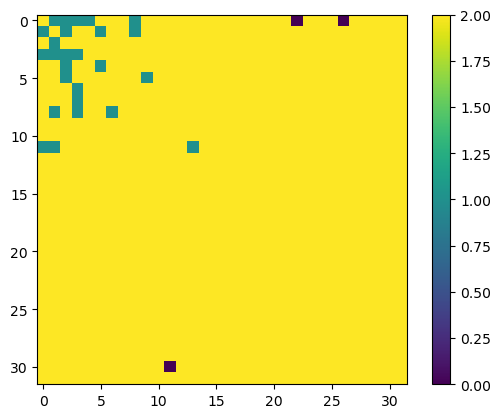

In [217]:
plt.imshow(grids[50])
plt.colorbar()
plt.show()

In [ ]:
%matplotlib qt

fig = plt.figure()

im = plt.imshow(grids[0], animated=True)

def updatefig(frame):
    im = plt.imshow(grids[frame], animated=True)
    return im,

ani = animation.FuncAnimation(fig, updatefig, frames=ts, interval=200)

plt.colorbar()
plt.show()